<div style="
  background: linear-gradient(145deg, #1a0b08, #2d1310);
  border: 4px solid transparent;
  border-radius: 14px;
  padding: 18px 22px;
  margin: 12px 0;
  font-size: 26px;
  font-weight: 600;
  color: #fff8f6;
  box-shadow: 0 6px 14px rgba(0,0,0,0.3);
  background-clip: padding-box;
  position: relative;
">
  <div style="
    position: absolute;
    inset: 0;
    padding: 4px;
    border-radius: 14px;
    background: linear-gradient(90deg, #ff7b00, #ff0054, #9d0208);
    -webkit-mask: 
      linear-gradient(#fff 0 0) content-box, 
      linear-gradient(#fff 0 0);
    -webkit-mask-composite: xor;
    mask-composite: exclude;
    pointer-events: none;
  "></div>
  
  <b>01 $\rightarrow$ Face Detection with OpenCV and Haar Cascades</b>
  <br>
  <span style="color:#ffb5a7; font-size: 18px;">(Human Face Localization & Multi-Face Detection Pipeline)</span>
</div>

---

## Overview
In this notebook, we implement **Human Face Detection** on static images using **Haar Feature-based Cascade Classifiers** (Viola-Jones framework).

### Key Concepts Covered:
1. Loading pre-trained Haar Cascades (`haarcascade_frontalface_default.xml`).
2. Color space preprocessing: **BGR $\to$ RGB $\to$ Grayscale**.
3. Non-destructive bounding box rendering.
4. Extracting and analyzing the cropped **Face Region of Interest (ROI)**.
5. **Multi-Face Detection**: Detecting, ordering, and isolating multiple faces in group photos.
6. **Hyperparameter Tuning**: Understanding the impact of `minNeighbors` on false positives and detection recall.

---

# Table of Contents 

1. [Import Libraries](#1-import-libraries)
2. [Load Pre-Trained Face Classifier](#2-load-pre-trained-face-classifier)
3. [Load and Prepare Single-Face Image](#3-load-and-prepare-single-face-image)
4. [Detect Face with detectMultiScale](#4-detect-face-with-detectmultiscale)
5. [Non-Destructive Detection Function](#5-non-destructive-detection-function)
6. [Single Face Visualizations](#6-single-face-visualizations)
   - 6.1 [Plot 1: 3-Panel Detection Pipeline Comparison](#61-plot-1-3-panel-detection-pipeline-comparison)
   - 6.2 [Plot 2: Cropped Face Region of Interest (ROI)](#62-plot-2-cropped-face-region-of-interest-roi)
7. [Multi-Face Detection on Group Image](#7-multi-face-detection-on-group-image)
   - 7.1 [Plot 3: Full Group Multi-Face Detection Comparison](#71-plot-3-full-group-multi-face-detection-comparison)
   - 7.2 [Plot 4: Cropped Face Gallery (All Individuals)](#72-plot-4-cropped-face-gallery-all-individuals)
8. [Hyperparameter Study: Understanding minNeighbors](#8-hyperparameter-study-understanding-minneighbors)
9. [Key Takeaways](#9-key-takeaways)

---

<a id="1-import-libraries"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">1. Import Libraries</span>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

<a id="2-load-pre-trained-face-classifier"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">2. Load Pre-Trained Face Classifier</span>

In [2]:
cascade_path = 'Haarcascades/haarcascade_frontalface_default.xml'
face_classifier = cv2.CascadeClassifier(cascade_path)

if face_classifier.empty():
    print("Error: Could not load cascade from:", cascade_path)
else:
    print("Face classifier loaded successfully!")

Face classifier loaded successfully!


<a id="3-load-and-prepare-single-face-image"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">3. Load and Prepare Single-Face Image</span>

In [3]:
image_bgr = cv2.imread('assets/images/eye_face.jpg')

# Convert color spaces
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

height, width, channels = image_rgb.shape
print(f"Image Resolution: {width} x {height} pixels, {channels} color channels")

Image Resolution: 1024 x 1024 pixels, 3 color channels


<a id="4-detect-face-with-detectmultiscale"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">4. Detect Face with `detectMultiScale`</span>

- **`scaleFactor=1.3`**: Image pyramid scale reduction step.
- **`minNeighbors=5`**: Number of neighbor candidate windows required to retain a detection.
- **`minSize=(30, 30)`**: Minimum object bounding size.

In [4]:
faces = face_classifier.detectMultiScale(image_gray, scaleFactor=1.3, minNeighbors=5, minSize=(30, 30))

print(f"Total faces detected: {len(faces)}")

if len(faces) == 0:
    print("No faces detected.")
else:
    for i, (x, y, w, h) in enumerate(faces, start=1):
        print(f"Face {i}: Position=({x}, {y}), Size={w}x{h} px")

Total faces detected: 1
Face 1: Position=(261, 196), Size=506x506 px


<a id="5-non-destructive-detection-function"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">5. Non-Destructive Detection Function</span>

In [5]:
def detect_face(image_rgb, image_gray, scale_factor=1.3, min_neighbors=5):
    canvas = image_rgb.copy()
    face_rects = face_classifier.detectMultiScale(image_gray, scaleFactor=scale_factor, minNeighbors=min_neighbors)
    
    for i, (x, y, w, h) in enumerate(face_rects, start=1):
        cv2.rectangle(canvas, (x, y), (x + w, y + h), (255, 0, 0), 6)
        cv2.putText(canvas, f"Face {i}", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)
        
    return canvas, face_rects

detected_image, detected_faces = detect_face(image_rgb, image_gray)

<a id="6-single-face-visualizations"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">6. Single Face Visualizations</span>

<a id="61-plot-1-3-panel-detection-pipeline-comparison"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.1 Plot 1: 3-Panel Detection Pipeline Comparison</span>

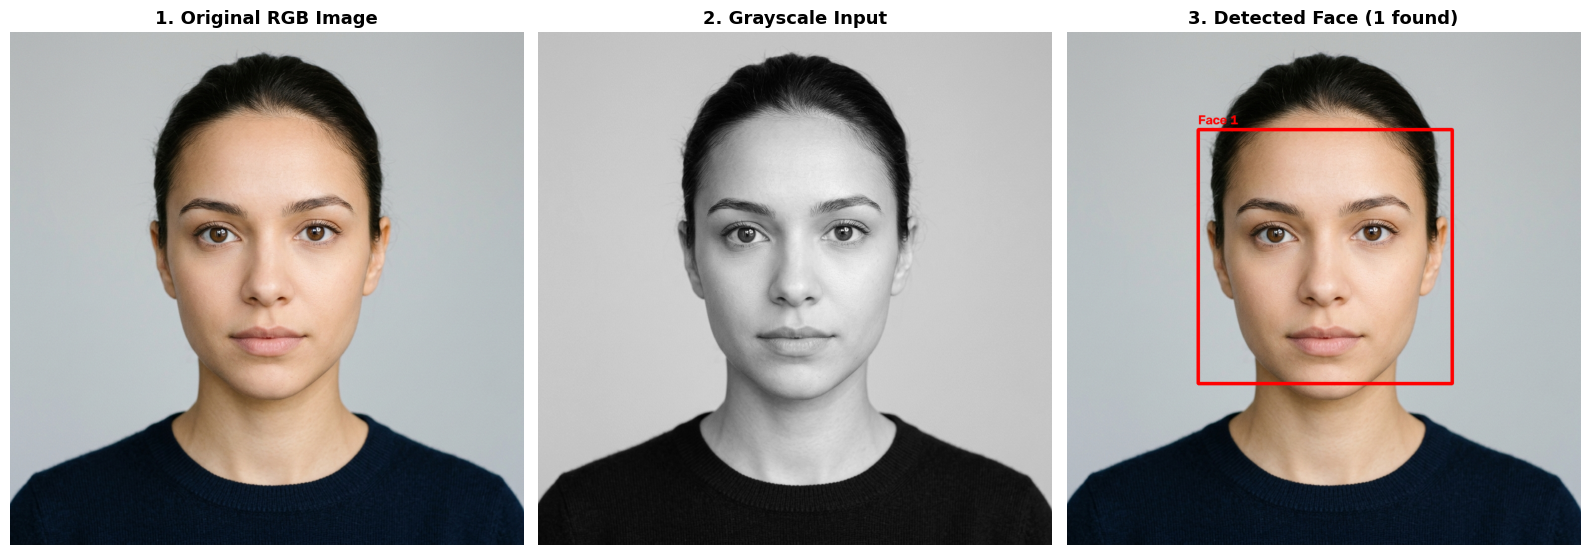

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

axes[0].imshow(image_rgb)
axes[0].set_title("1. Original RGB Image", fontsize=13, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(image_gray, cmap='gray')
axes[1].set_title("2. Grayscale Input", fontsize=13, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(detected_image)
axes[2].set_title(f"3. Detected Face ({len(detected_faces)} found)", fontsize=13, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

<a id="62-plot-2-cropped-face-region-of-interest-roi"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.2 Plot 2: Cropped Face Region of Interest (ROI)</span>

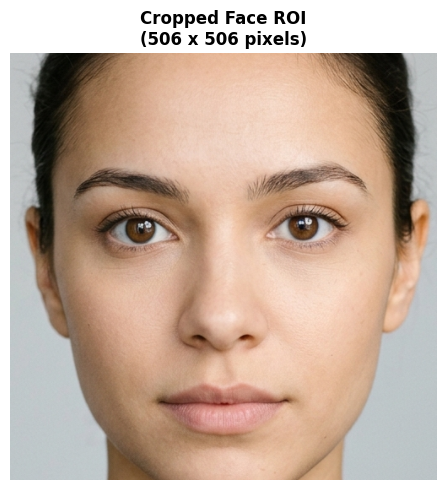

In [7]:
if len(detected_faces) > 0:
    x, y, w, h = detected_faces[0]
    face_roi = image_rgb[y:y+h, x:x+w]
    
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(face_roi)
    ax.set_title(f"Cropped Face ROI\n({w} x {h} pixels)", fontsize=12, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

<a id="7-multi-face-detection-on-group-image"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">7. Multi-Face Detection on Group Image</span>

In real-world computer vision systems, images often contain multiple people standing at varying depths and positions.

Here we apply our detector to a group photo (`assets/images/multiple_faces.jpg`).

In [8]:
group_bgr = cv2.imread('assets/images/multiple_faces.jpg')
group_rgb = cv2.cvtColor(group_bgr, cv2.COLOR_BGR2RGB)
group_gray = cv2.cvtColor(group_bgr, cv2.COLOR_BGR2GRAY)

# Detect all faces in group
group_faces = face_classifier.detectMultiScale(
    group_gray,
    scaleFactor=1.2,
    minNeighbors=5,
    minSize=(60, 60)
)

# Sort faces left-to-right by X coordinate
group_faces = sorted(group_faces, key=lambda box: box[0])

print(f"Total faces detected: {len(group_faces)}")
for idx, (x, y, w, h) in enumerate(group_faces, start=1):
    print(f"Person #{idx}: X={x}, Y={y}, Width={w}px, Height={h}px")

Total faces detected: 5
Person #1: X=180, Y=341, Width=152px, Height=152px
Person #2: X=401, Y=246, Width=148px, Height=148px
Person #3: X=563, Y=377, Width=128px, Height=128px
Person #4: X=749, Y=278, Width=147px, Height=147px
Person #5: X=942, Y=367, Width=153px, Height=153px


In [9]:
# Annotate faces on group image
group_canvas = group_rgb.copy()

for idx, (x, y, w, h) in enumerate(group_faces, start=1):
    cv2.rectangle(group_canvas, (x, y), (x + w, y + h), (255, 0, 0), 4)
    cv2.putText(group_canvas, f"#{idx}", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)

<a id="71-plot-3-full-group-multi-face-detection-comparison"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">7.1 Plot 3: Full Group Multi-Face Detection Comparison</span>

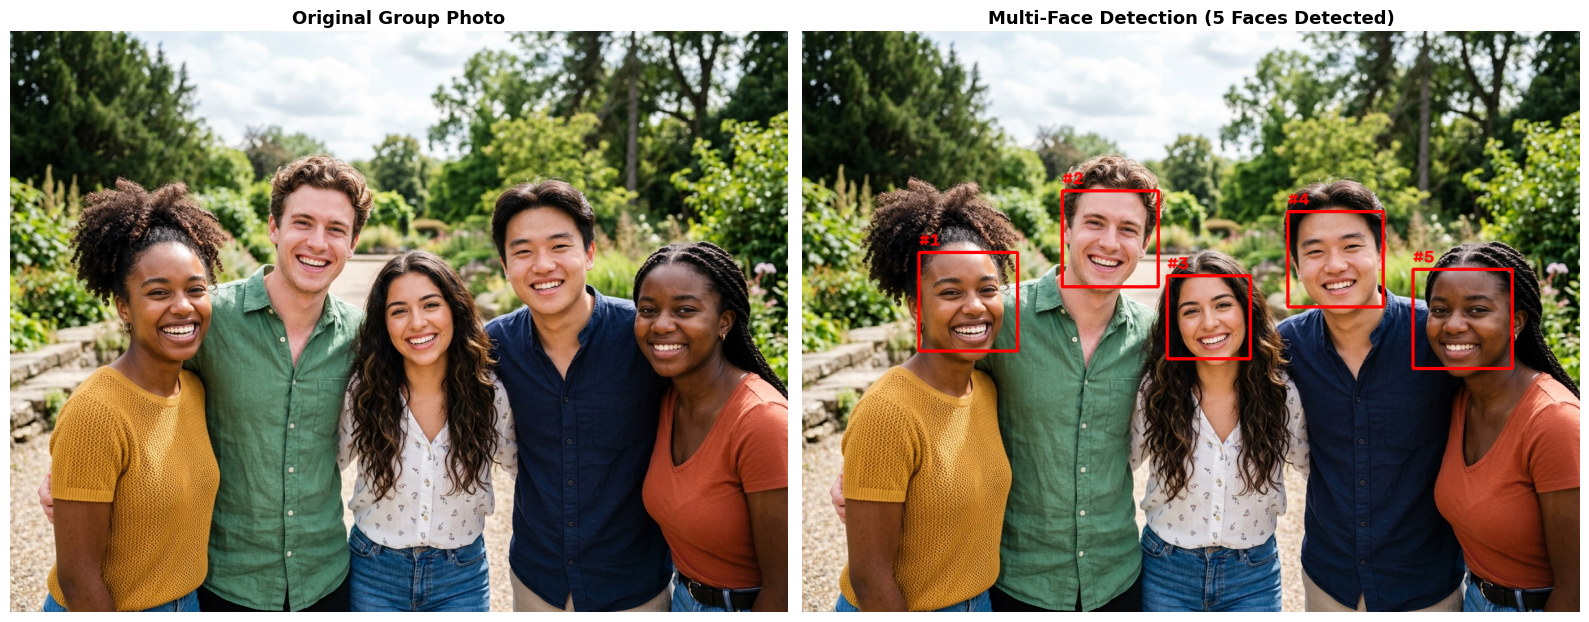

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(group_rgb)
axes[0].set_title("Original Group Photo", fontsize=13, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(group_canvas)
axes[1].set_title(f"Multi-Face Detection ({len(group_faces)} Faces Detected)", fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

<a id="72-plot-4-cropped-face-gallery-all-individuals"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">7.2 Plot 4: Cropped Face Gallery (All Individuals)</span>

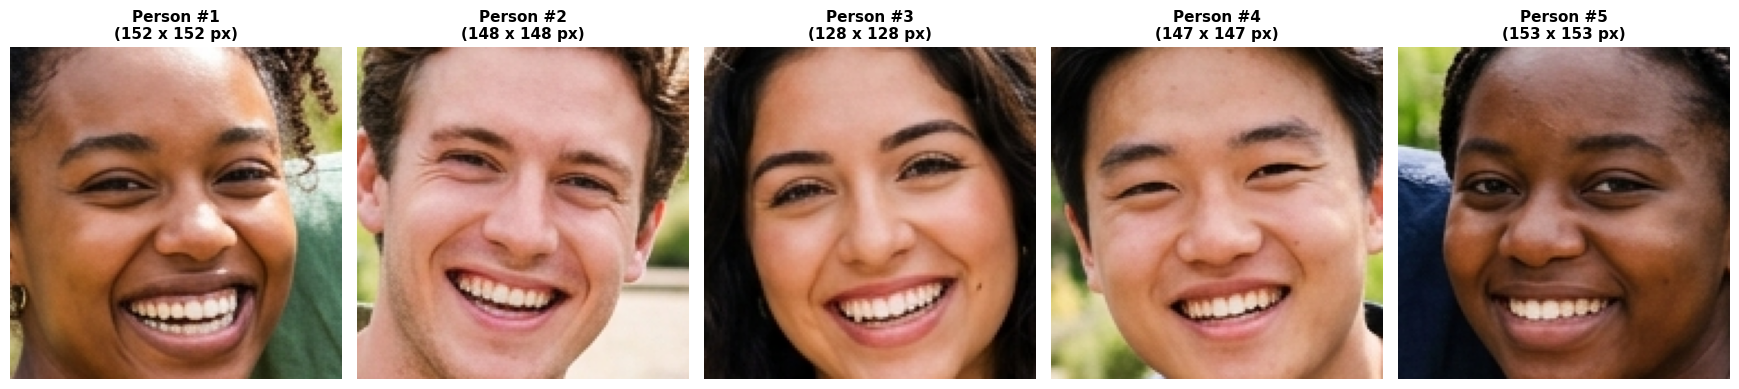

In [11]:
if len(group_faces) > 0:
    fig, axes = plt.subplots(1, len(group_faces), figsize=(3.5 * len(group_faces), 4))
    
    if len(group_faces) == 1:
        axes = [axes]
        
    for idx, (x, y, w, h) in enumerate(group_faces):
        cropped_face = group_rgb[y:y+h, x:x+w]
        axes[idx].imshow(cropped_face)
        axes[idx].set_title(f"Person #{idx + 1}\n({w} x {h} px)", fontsize=11, fontweight='bold')
        axes[idx].axis('off')
        
    plt.tight_layout()
    plt.show()

<a id="8-hyperparameter-study-understanding-minneighbors"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">8. Hyperparameter Study: Understanding `minNeighbors`</span>

The `minNeighbors` parameter defines how many overlapping candidate rectangles are required to confirm a face:
- **Low `minNeighbors` (e.g. 2)**: High recall but risks **false positives** (detecting non-face patterns).
- **Optimal `minNeighbors` (e.g. 5)**: Balances recall and precision (detects all real faces).
- **High `minNeighbors` (e.g. 10)**: Strict threshold that risks **false negatives** (missing valid faces).

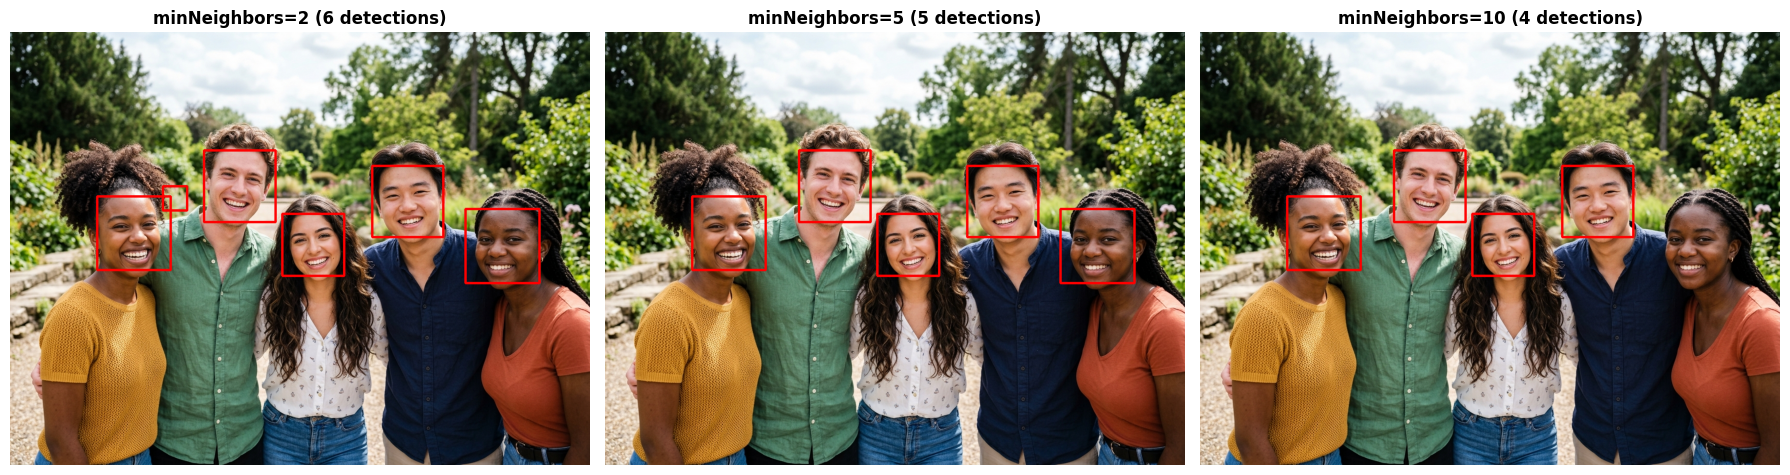

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
neighbor_settings = [2, 5, 10]

for i, mn in enumerate(neighbor_settings):
    canvas_test = group_rgb.copy()
    test_boxes = face_classifier.detectMultiScale(group_gray, scaleFactor=1.2, minNeighbors=mn, minSize=(50, 50))
    
    for (x, y, w, h) in test_boxes:
        cv2.rectangle(canvas_test, (x, y), (x + w, y + h), (255, 0, 0), 4)
        
    axes[i].imshow(canvas_test)
    axes[i].set_title(f"minNeighbors={mn} ({len(test_boxes)} detections)", fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

<a id="9-key-takeaways"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">9. Key Takeaways</span>

- **Preprocessing**: Grayscale conversion is essential for Haar feature calculations.
- **Tuning `minNeighbors`**: Always start around `minNeighbors=4-6` and adjust based on false positive vs false negative rates.
- **Multi-Face**: Sorting bounding boxes by X coordinates helps maintain an orderly visual index of detected individuals.
- **Next Step**: In Notebook 02, we examine eye detection and analyze the challenge of false positives during unconstrained feature search.